<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Stock%20Performance%20and%20US%20Treasury%20Bills/Global_Stocks_and_Tbills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bessembinder (2019) analyzed a comprehensive dataset of over 26,000 global companies, covering many international markets, which required access to expensive institutional financial data. I do not have access to such complete datasets. This Colab notebook uses a much smaller subset of data from the S&P 500 and the Moscow Exchange to illustrate the key principles from Bessembinder’s work. While these results demonstrate concepts such as survivorship bias and the concentration of stock returns, they do not represent the full global market analysis or the exact statistics from his study.

I used the data 'sp500_changes_since_2019.csv', 'sp500.csv', and 'sp500_ticker_start_end.csv' for this.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving DGS1MO.csv to DGS1MO.csv


Survivors:
Non-survivors:
Survivors (n=142): 89.4% beat T-bills | median return 355.4% | skew 11.15
Non-Survivors (n=30): 40.0% beat T-bills | median return -44.2% | skew 3.44
Combined (n=172): 80.8% beat T-bills | median return 242.5% | skew 12.23
Bessembinder (2019): ~44% beat T-bills


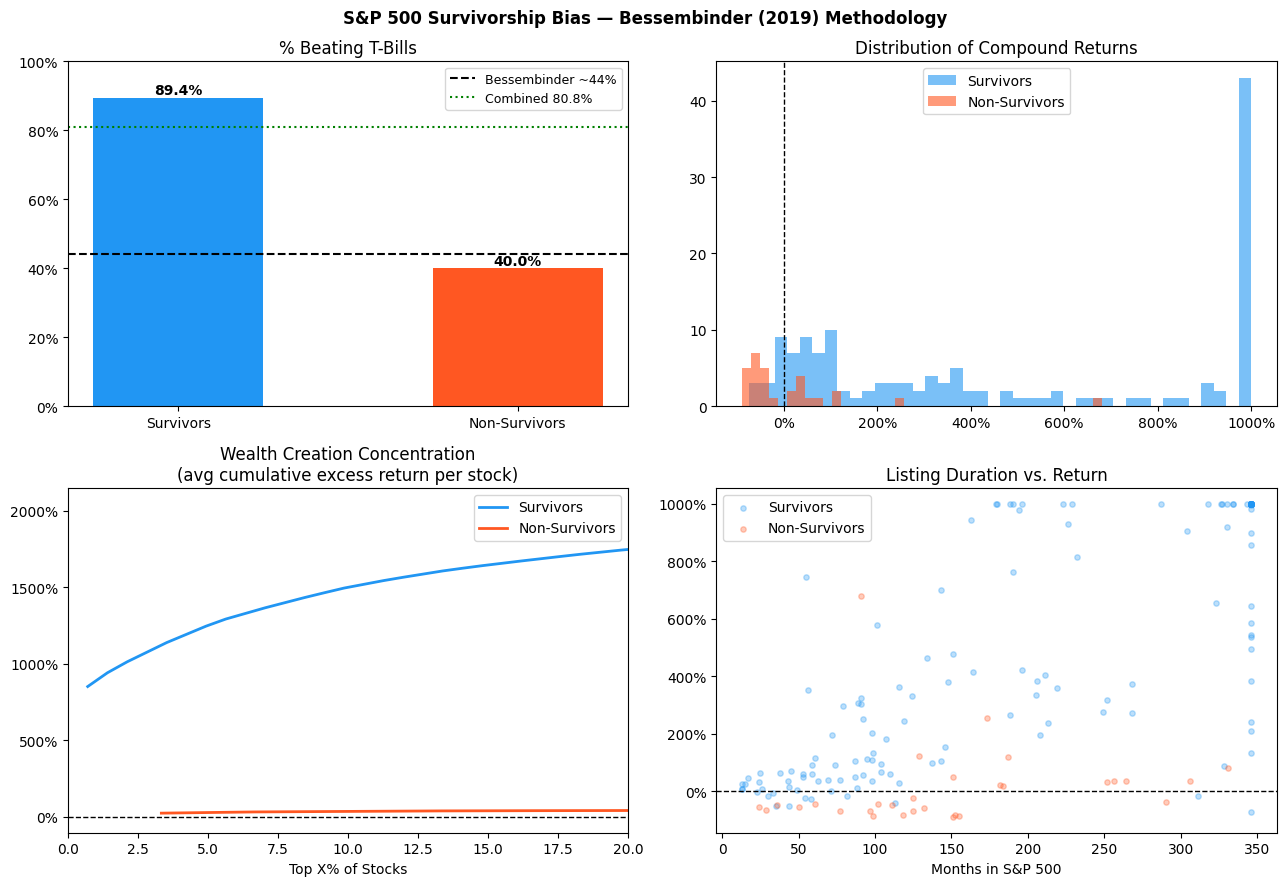

In [7]:
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

# ── 1. LOAD FILES ────────────────────────────────────────────
tickers = pd.read_csv("/content/sp500_ticker_start_end.csv", parse_dates=["start_date","end_date"])
tickers["end_date"] = tickers["end_date"].fillna(pd.Timestamp("2024-12-31"))
tickers = tickers.sort_values("end_date").drop_duplicates("ticker", keep="last")

current = set(pd.read_csv("/content/sp500.csv")["Symbol"])
tickers["survivor"] = tickers["ticker"].isin(current)

tbill = pd.read_csv("/content/DGS1MO.csv", parse_dates=["observation_date"], index_col="observation_date")
tbill = pd.to_numeric(tbill["DGS1MO"], errors="coerce").resample("ME").mean().dropna() / 100 / 12

# ── 2. FUNCTIONS ─────────────────────────────────────────────
def get_returns(ticker, start, end):
    try:
        # skip if date range is invalid
        if pd.Timestamp(start) >= pd.Timestamp(end): return None
        df = yf.download(ticker, start=start, end=end, interval="1mo",
                         auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
        r = df["Close"].dropna().pct_change().dropna()
        return r if len(r) >= 12 else None
    except: return None

def analyze(rows):
    out = []
    for i, r in enumerate(rows.itertuples()):
        if i % 25 == 0: print(f"  {i}/{len(rows)}", end="\r")
        rets = get_returns(r.ticker, str(r.start_date.date()), str(r.end_date.date()))
        if rets is None: continue
        stock = (1 + rets).prod() - 1
        bench = tbill.reindex(rets.index, method="ffill").dropna()
        if len(bench) < 6: continue
        tb = (1 + bench).prod() - 1
        out.append({"ticker": r.ticker, "survivor": r.survivor,
                    "stock": stock, "tbill": tb, "beats": stock > tb,
                    "months": len(rets)})
    return pd.DataFrame(out)

# ── 3. RUN ───────────────────────────────────────────────────
N = 150
surv = tickers[tickers["survivor"]].sample(N, random_state=42)
non  = tickers[~tickers["survivor"]].sample(N, random_state=42)

print("Survivors:");     df_s = analyze(surv)
print("Non-survivors:"); df_n = analyze(non)
df = pd.concat([df_s, df_n])

# ── 4. PRINT RESULTS ─────────────────────────────────────────
for lbl, g in [("Survivors", df_s), ("Non-Survivors", df_n), ("Combined", df)]:
    print(f"{lbl} (n={len(g)}): {g['beats'].mean()*100:.1f}% beat T-bills | "
          f"median return {g['stock'].median()*100:.1f}% | skew {g['stock'].skew():.2f}")
print("Bessembinder (2019): ~44% beat T-bills")

# ── 5. PLOTS ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("S&P 500 Survivorship Bias — Bessembinder (2019) Methodology", fontweight="bold")
c = {"Survivors": "#2196F3", "Non-Survivors": "#FF5722"}

ax = axes[0,0]
vals = [df_s["beats"].mean()*100, df_n["beats"].mean()*100]
bars = ax.bar(["Survivors", "Non-Survivors"], vals, color=list(c.values()), width=0.5)
ax.axhline(44, color="black", linestyle="--", lw=1.5, label="Bessembinder ~44%")
ax.axhline(df["beats"].mean()*100, color="green", linestyle=":", lw=1.5, label=f"Combined {df['beats'].mean()*100:.1f}%")
[ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontweight="bold") for b,v in zip(bars,vals)]
ax.set_ylim(0,100); ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=9)
ax.set_title("% Beating T-Bills")

ax = axes[0,1]
for lbl, g in [("Survivors", df_s), ("Non-Survivors", df_n)]:
    ax.hist(g["stock"].clip(-1,10), bins=40, alpha=0.6, label=lbl, color=c[lbl])
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Distribution of Compound Returns"); ax.legend()

ax = axes[1,0]
for lbl, g in [("Survivors", df_s), ("Non-Survivors", df_n)]:
    wc  = (g["stock"] - g["tbill"]).sort_values(ascending=False).reset_index(drop=True)
    # normalize by total stocks so both groups are comparable
    cum = wc.cumsum() / len(g)
    ax.plot(np.arange(1,len(cum)+1)/len(cum)*100, cum, label=lbl, color=c[lbl], lw=2)
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.set_xlim(0, 20)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Top X% of Stocks")
ax.set_title("Wealth Creation Concentration\n(avg cumulative excess return per stock)")
ax.legend()

ax = axes[1,1]
for lbl, g in [("Survivors", df_s), ("Non-Survivors", df_n)]:
    ax.scatter(g["months"], g["stock"].clip(-1,10), alpha=0.3, s=15, label=lbl, color=c[lbl])
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Months in S&P 500"); ax.set_title("Listing Duration vs. Return"); ax.legend()

plt.tight_layout()
plt.savefig("survivorship_bias.png", dpi=150, bbox_inches="tight")
plt.show()
df.to_csv("results.csv", index=False)

This analysis of S&P 500 stocks illustrates the core idea from Bessembinder (2019) about survivorship bias and stock performance, even though it doesn’t use the full market data. Here, survivors show much higher success rates (89.4% beating T-Bills) and returns than non-survivors (40% beating T-Bills), leading to a combined rate (80.8%) that still overstates the true market-wide performance. Bessembinder’s broader study, which includes all stocks, found only about 44% beat T-Bills, highlighting how limited samples like the S&P 500 exclude many failing stocks and create a misleadingly positive picture of stock returns. This partial data therefore supports the concept without fully capturing the full market reality Bessembinder describes.


Fetching securities...
Total: 412 | Active: 260 | Delisted: 152

Testing SBER...
SBER: 121 monthly returns

Analysing active...


Active:   0%|          | 0/260 [00:00<?, ?ticker/s]

  [Active] Valid: 212/260
Analysing delisted...


Delisted:   0%|          | 0/152 [00:00<?, ?ticker/s]

  [Delisted] Valid: 119/152

Active (n=212): 58.5% beat T-bill | median 49.8% | skew 14.42
Delisted (n=119): 36.1% beat T-bill | median -13.3% | skew 7.07
Combined (n=331): 50.5% beat T-bill | median 8.7% | skew 17.93
Bessembinder (2019): ~44%


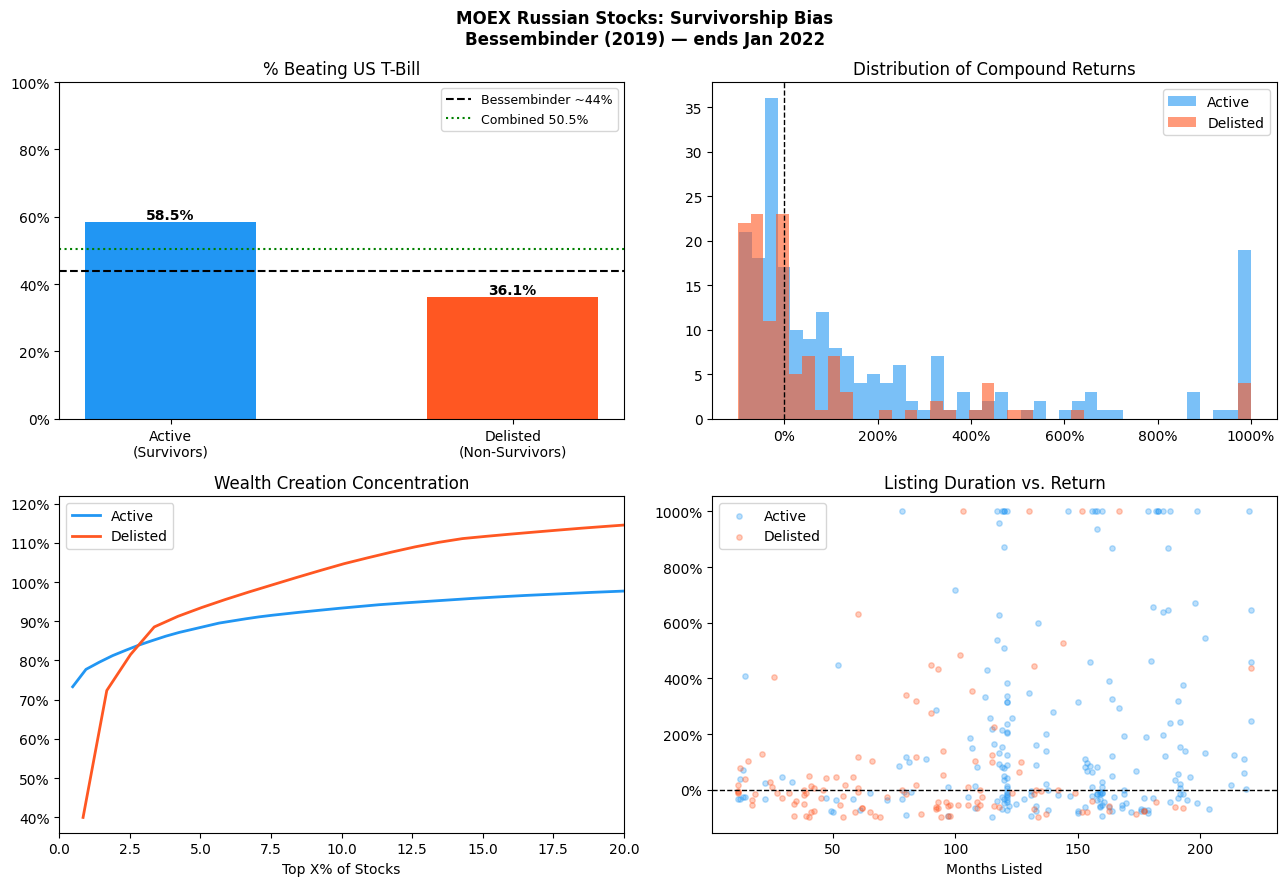

In [5]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

BASE = "https://iss.moex.com/iss"
END  = "2022-01-01"
WORKERS = 20  # parallel threads — increase if no errors, decrease if timeouts

# ── 1. GET ALL SECURITIES ────────────────────────────────────
def get_all_securities():
    rows, start = [], 0
    while True:
        r = requests.get(f"{BASE}/securities.json", params={
            "engine": "stock", "market": "shares", "is_traded": 0,
            "start": start,
            "securities.columns": "secid,shortname,is_traded,primary_boardid"
        }).json()
        data = r["securities"]["data"]
        if not data: break
        rows.extend(data); start += 100
    cols = r["securities"]["columns"]
    df = pd.DataFrame(rows, columns=cols)
    return df[df["primary_boardid"].isin(["TQBR", "TQBS"])]

print("Fetching securities..."); secs = get_all_securities()
print(f"Total: {len(secs)} | Active: {secs['is_traded'].sum()} | Delisted: {(secs['is_traded']==0).sum()}")

# ── 2. FETCH ONE TICKER (all pages) ─────────────────────────
def fetch_ticker(secid):
    rows, start = [], 0
    session = requests.Session()
    while True:
        try:
            r = session.get(
                f"{BASE}/history/engines/stock/markets/shares/securities/{secid}.json",
                params={"from": "2000-01-01", "till": END,
                        "history.columns": "TRADEDATE,CLOSE", "start": start},
                timeout=10
            ).json()
            data = r["history"]["data"]
            if not data: break
            rows.extend(data); start += 100
        except: break
    if len(rows) < 12: return secid, None
    df = pd.DataFrame(rows, columns=["date", "close"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna().set_index("date").sort_index()
    monthly = df["close"].resample("ME").last().dropna()
    if len(monthly) < 12: return secid, None
    return secid, monthly.pct_change().dropna()

# ── 3. PARALLEL ANALYSIS ─────────────────────────────────────
def analyze_parallel(tickers, label):
    out = []
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futures = {ex.submit(fetch_ticker, t): t for t in tickers}
        with tqdm(total=len(tickers), desc=label, unit="ticker") as pbar:
            for f in as_completed(futures):
                secid, rets = f.result()
                if rets is not None:
                    stock = (1 + rets).prod() - 1
                    bench = rfr.reindex(rets.index, method="ffill").dropna()
                    if len(bench) >= 6:
                        tb = (1 + bench).prod() - 1
                        out.append({"ticker": secid, "stock": stock, "rfr": tb,
                                    "beats": stock > tb, "months": len(rets)})
                pbar.update(1)
    print(f"  [{label}] Valid: {len(out)}/{len(tickers)}")
    return pd.DataFrame(out)

# ── 4. LOAD T-BILL ───────────────────────────────────────────
rfr = pd.read_csv("/content/DGS1MO.csv", parse_dates=["observation_date"], index_col="observation_date")
rfr = pd.to_numeric(rfr["DGS1MO"], errors="coerce").resample("ME").mean().dropna() / 100 / 12

# sanity check
print("\nTesting SBER...")
_, test = fetch_ticker("SBER")
print(f"SBER: {len(test) if test is not None else 0} monthly returns")

# ── 5. RUN ───────────────────────────────────────────────────
active   = secs[secs["is_traded"] == 1]["secid"].tolist()
delisted = secs[secs["is_traded"] == 0]["secid"].tolist()

print("\nAnalysing active..."); df_a = analyze_parallel(active,   "Active")
print("Analysing delisted..."); df_d = analyze_parallel(delisted, "Delisted")
df = pd.concat([df_a, df_d])

# ── 6. RESULTS ───────────────────────────────────────────────
print("\n" + "="*55)
for lbl, g in [("Active", df_a), ("Delisted", df_d), ("Combined", df)]:
    print(f"{lbl} (n={len(g)}): {g['beats'].mean()*100:.1f}% beat T-bill | "
          f"median {g['stock'].median()*100:.1f}% | skew {g['stock'].skew():.2f}")
print("Bessembinder (2019): ~44%")

# ── 7. PLOTS ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("MOEX Russian Stocks: Survivorship Bias\nBessembinder (2019) — ends Jan 2022", fontweight="bold")
c = {"Active": "#2196F3", "Delisted": "#FF5722"}

ax = axes[0,0]
vals = [df_a["beats"].mean()*100, df_d["beats"].mean()*100]
bars = ax.bar(["Active\n(Survivors)", "Delisted\n(Non-Survivors)"], vals,
              color=[c["Active"], c["Delisted"]], width=0.5)
ax.axhline(44, color="black", linestyle="--", lw=1.5, label="Bessembinder ~44%")
ax.axhline(df["beats"].mean()*100, color="green", linestyle=":", lw=1.5,
           label=f"Combined {df['beats'].mean()*100:.1f}%")
[ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontweight="bold")
 for b, v in zip(bars, vals)]
ax.set_ylim(0,100); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9); ax.set_title("% Beating US T-Bill")

ax = axes[0,1]
for lbl, g in [("Active", df_a), ("Delisted", df_d)]:
    ax.hist(g["stock"].clip(-1,10), bins=40, alpha=0.6, label=lbl, color=c[lbl])
ax.axvline(0, color="black", linestyle="--", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Distribution of Compound Returns"); ax.legend()

ax = axes[1,0]
for lbl, g in [("Active", df_a), ("Delisted", df_d)]:
    wc  = (g["stock"] - g["rfr"]).sort_values(ascending=False).reset_index(drop=True)
    cum = wc.cumsum() / wc.sum() * 100
    ax.plot(np.arange(1,len(cum)+1)/len(cum)*100, cum, label=lbl, color=c[lbl], lw=2)
ax.set_xlim(0,20); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Top X% of Stocks"); ax.set_title("Wealth Creation Concentration"); ax.legend()

ax = axes[1,1]
for lbl, g in [("Active", df_a), ("Delisted", df_d)]:
    ax.scatter(g["months"], g["stock"].clip(-1,10), alpha=0.3, s=15, label=lbl, color=c[lbl])
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Months Listed"); ax.set_title("Listing Duration vs. Return"); ax.legend()

plt.tight_layout()
plt.savefig("moex_survivorship_bias.png", dpi=150, bbox_inches="tight")
plt.show()
df.to_csv("moex_results.csv", index=False)

This analysis of MOEX Russian stocks shows that 58.5% of active (surviving) stocks beat the US T-Bill, with a median return of 49.8%, while only 36.1% of delisted (non-surviving) stocks beat the T-Bill, with a median return of –13.3%. When combined, 50.5% of all stocks beat the T-Bill, with a median return of 8.7%. These results are higher than Bessembinder’s broader finding that about 44% of all stocks beat T-Bills, reflecting that this dataset is limited to MOEX stocks and a smaller sample size. Nonetheless, this data highlights the survivorship bias effect, where focusing only on surviving stocks overstates overall market performance by ignoring the poor returns of delisted companies.


You might have noticed that the wealth creation concentration graphs for Russia and the S&P 500 look very different. This is because Russian stocks (MOEX) had genuinely high returns even among delisted companies due to an emerging market boom from 2000 to 2022. Many stocks including those eventually removed still made money in absolute terms which kept both active and delisted lines above zero. In contrast S&P 500 non-survivors typically lost money versus T-Bills as companies removed from the index often underperformed badly because of bankruptcy or acquisitions at a loss causing their returns to fall below zero. In short the Russian market was a rising tide lifting most boats while S&P 500 non-survivors were genuinely poor investments. This matches Bessembinder’s findings comparing emerging and developed markets where emerging markets had higher average returns that inflate the percentage beating T-Bills even among losers. It also highlights an important methodological point that comparing Russian stocks to the US T-Bill rate instead of a Russian interest rate may artificially boost Russian performance numbers since Russian interest rates were much higher than US rates for most of this period something worth noting in your write-up.
